module://matplotlib_inline.backend_inline


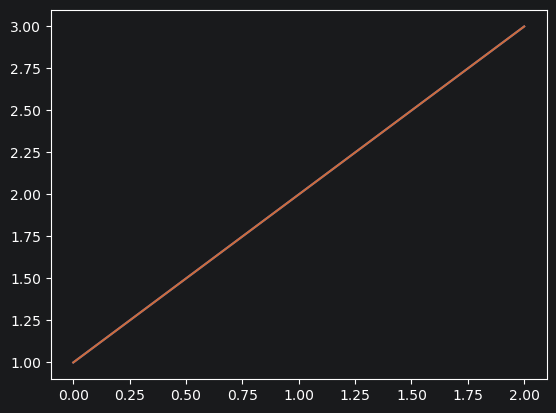

finished


In [2]:
%matplotlib inline

import matplotlib

matplotlib.rcParams['backend'] = 'module://matplotlib_inline.backend_inline'

import matplotlib.pyplot as plt

print(matplotlib.get_backend())

plt.plot([1,2,3])
plt.show()
print("finished")

In [3]:
import torch
from src.model import SequenceCNN

model = SequenceCNN()

model.load_state_dict(
    torch.load(
        "../models/liver_accessibility_cnn.pth"
    )
)

model.eval()

SequenceCNN(
  (conv1): Conv1d(4, 32, kernel_size=(5,), stride=(1,))
  (relu): ReLU()
  (pool): AdaptiveMaxPool1d(output_size=1)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)

In [4]:
import pandas as pd

dataset_df = pd.read_csv(
    "../data/processed/liver_accessibility_gc_matched.csv"
)

In [5]:
from src.datasets import SequenceDataset

dataset = SequenceDataset(
    "../data/processed/liver_accessibility_gc_matched.csv"
)

In [6]:
FILTER_INDEX = 0
top_motifs = []

for i in range(1000):

    sample_x, sample_y, chrom = dataset[i]

    sample_x = sample_x.unsqueeze(0)

    conv_output = model.conv1(sample_x)

    activations = (
        conv_output[
            0,
            FILTER_INDEX
        ]
        .detach()
        .numpy()
    )

    max_position = activations.argmax()

    max_activation = activations.max()

    sequence = dataset_df.iloc[i]["sequence"]

    motif_candidate = sequence[
        max_position:max_position + 5
    ]

    top_motifs.append({
        "motif": motif_candidate,
        "activation": max_activation
    })

In [7]:
top_motifs = sorted(
    top_motifs,
    key=lambda x: x["activation"],
    reverse=True
)

In [8]:
for entry in top_motifs[:20]:

    print(
        entry["motif"],
        entry["activation"]
    )

GTCAC 1.7700458
GTCAC 1.7700458
GTCAC 1.7700458
GTCAC 1.7700458
GTCAC 1.7700458
GTCAC 1.7700458
GTCAC 1.7700458
GTCAC 1.7700458
GTCAC 1.7700458
GTCAC 1.7700458
GTCAC 1.7700458
GTCAC 1.7700458
GTCAC 1.7700458
GTCAC 1.7700458
GTCAC 1.7700458
GTCAC 1.7700458
GTCAC 1.7700458
GTCAC 1.7700458
GTCAC 1.7700458
GTCAC 1.7700458


In [9]:
seen = set()

unique_top_motifs = []

for entry in top_motifs:

    motif = entry["motif"]

    if motif not in seen:

        unique_top_motifs.append(entry)

        seen.add(motif)

In [10]:
for entry in unique_top_motifs[:20]:

    print(
        entry["motif"],
        entry["activation"]
    )

GTCAC 1.7700458
GTTAC 1.6055
GTCAT 1.5415322
GTCAA 1.4355824
GTTAT 1.3769863
GTTAA 1.2710364
GTCGC 1.1177363
GTGAC 1.0335562
GTCAG 0.9903168
GTTGC 0.95319045
GTAAC 0.9057468
GTCGT 0.8892228
TTCAC 0.83390856
GTTAG 0.82577085
GTGAT 0.80504256
GTCGA 0.78327304
GCCAC 0.7692041
GTCTC 0.7450495
ATCAC 0.74149513
GTTGT 0.7246768


In [11]:
top_sequences = [
    entry["motif"]
    for entry in unique_top_motifs[:100]
]

In [12]:
import numpy as np

pfm = np.zeros((4, 5)) #Position Frequency Matrix

nucleotide_to_index = {
    "A": 0,
    "C": 1,
    "G": 2,
    "T": 3
}

for sequence in top_sequences:

    for position, nucleotide in enumerate(sequence):

        row = nucleotide_to_index[
            nucleotide
        ]

        pfm[row, position] += 1

pfm = pfm / pfm.sum(axis=0)

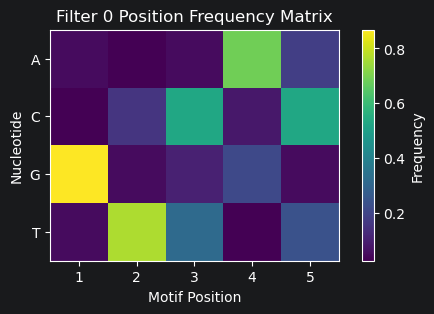

In [13]:
plt.figure(figsize=(6, 3))

plt.imshow(pfm)

plt.yticks(
    [0, 1, 2, 3],
    ["A", "C", "G", "T"]
)

plt.xticks(
    range(5),
    range(1, 6)
)

plt.xlabel("Motif Position")
plt.ylabel("Nucleotide")

plt.colorbar(label="Frequency")

plt.title("Filter 0 Position Frequency Matrix")

plt.show()